# Syllable composition over the trial

Trial-aligned syllable histograms: one stacked column per time bin, showing what fraction of
trials were in each paw state at that moment. Same construction as fig 2A, drawn through
`paper_style` so the palette and the stacking order are shared.

Group the same plot by **session**, **mouse**, **trial type**, or **position along an LD
axis** — one knob. The LD grouping is the one that shows the individuality result directly:
LD3 is the laterality axis, so its extremes should come out blue (left) against orange
(right).

**Colour = paw**: hue is which forepaw leads, lightness is vigor (`ps.PAW_STATE_COLORS`).
**Whisk and lick** are proportions, drawn as a band and a line underneath — or, with
`TEXTURE = True`, laid over the stack as hatching.

In [10]:
# ---- SHARED FIGURE STYLE ------------------------------------------------------------
import sys, pathlib, importlib

_p = pathlib.Path.cwd().resolve()
while not (_p / 'paper_style.py').exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
import paper_style
importlib.reload(paper_style)   # kernels cache modules; without this, edits stay invisible
ps = paper_style
ps.use('paper')                 # 'paper' = journal sizes; 'poster' = big type
ROOT = str(_p) + '/'

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


In [11]:
"""IMPORTS AND FILES"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SYLLABLE_FILE = ROOT + 'data/8_k_10_bin_syllables_19-08-2026'
EMBEDDING = ROOT + 'clustering/data_files/mouse_LDA_5_bins_raw_shrink0.5_360_24-09-2026'
EPOCHS = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
TRIAL_FIELDS = ['feedback', 'contrast', 'block', 'side']   # the trial_type string, in order

## Knobs

`GROUP_BY` is the only one that changes what the figure is about.

| value | one panel per |
|---|---|
| `'session'` | the `N_GROUPS` sessions with most trials |
| `'mouse'` | a mouse, pooling all its sessions |
| `'trial_type'` | a level of `TRIAL_FIELD` |
| `'ld_extremes'` | a session sampled evenly along discriminant `LD` |

**`TRIAL_FIELD = 'side'` is a trap.** That field comes from the choice strings, which are
**mirrored** in this dataset — `'left'` is not the left side. Orient left/right on `'block'`
(probabilityLeft) instead. The knob still allows `'side'` because it is fine for asking
*whether* the two choice categories differ; just do not read the labels.

In [12]:
GROUP_BY    = 'session'   # 'session' | 'mouse' | 'trial_type' | 'ld_extremes'
N_GROUPS    = 5

TEXTURE     = True           # whisk (//) and lick (..) hatched OVER the stack, so one panel
                             # carries paw side, paw vigor, whisking and licking together.
                             # The panel is then widened automatically: a hatch needs
                             # ps.HATCH_MIN_PT per bin, which for 40 bins is ~6.7 in.
                             # False instead draws whisking and licking as proportions in a
                             # strip underneath, which stays legible at any width and keeps
                             # the laterality contrast louder -- texture splits most paw
                             # blocks in two, adding edges that are not paw transitions.

LD          = 3              # 1-indexed. LD3 is the laterality axis.
TRIAL_FIELD = 'block'        # feedback | contrast | block | side  -- read the note above
MIN_TRIALS  = 25             # a trial-type level below this is dropped rather than drawn
                             # from a handful of trials

In [13]:
"""LOAD"""
seq = pd.read_parquet(SYLLABLE_FILE)
seq['session'] = seq['sample'].str[:36]
emb = pd.read_pickle(EMBEDDING)
print(f"{seq['session'].nunique()} sessions, {seq['mouse_name'].nunique()} mice in the "
      f"syllable file; the embedding covers {len(emb)} of them")

332 sessions, 101 mice in the syllable file; the embedding covers 260 of them


## What the eight states are

Before any composition plot, the two quantities the palette encodes, per state:

- **Vigor** — mean z-scored wavelet power over both forepaws, both image axes and the whole
  0.5–8 Hz band (`state_laterality()['overall']`). It sets **lightness**. Being a z-score it
  is relative, so the quiet states are negative rather than zero, and because it averages
  across frequencies it is *total power*, not speed: state 2 is slow and large, state 3 fast
  and small, and they land at similar vigor.
- **Left − right gap** — the absolute asymmetry between the paws. It sets **chroma**, and
  the sign sets **hue**. Deliberately not the laterality index `LI = (L−R)/(|L|+|R|)`, whose
  denominator collapses for the quiet states and turns state 1's 0.045 gap into LI +0.13.

Occupancy is shown alongside because it is what makes the extremes readable in context:
state 7 has by far the largest vigor but is 0.7% of bins, so it is a rare flourish rather
than something a session is made of.

States are ordered by vigor, not by their HMM numbers, which are arbitrary — see
`ps.PAW_VIGOR_ORDER`.

not saved (ps.SAVE_FIGURES is False): figures/paw_state_characterisation_27-09-2026.png, figures/paw_state_characterisation_27-09-2026.svg   -- ps.saving(True) to write, or pass save=True


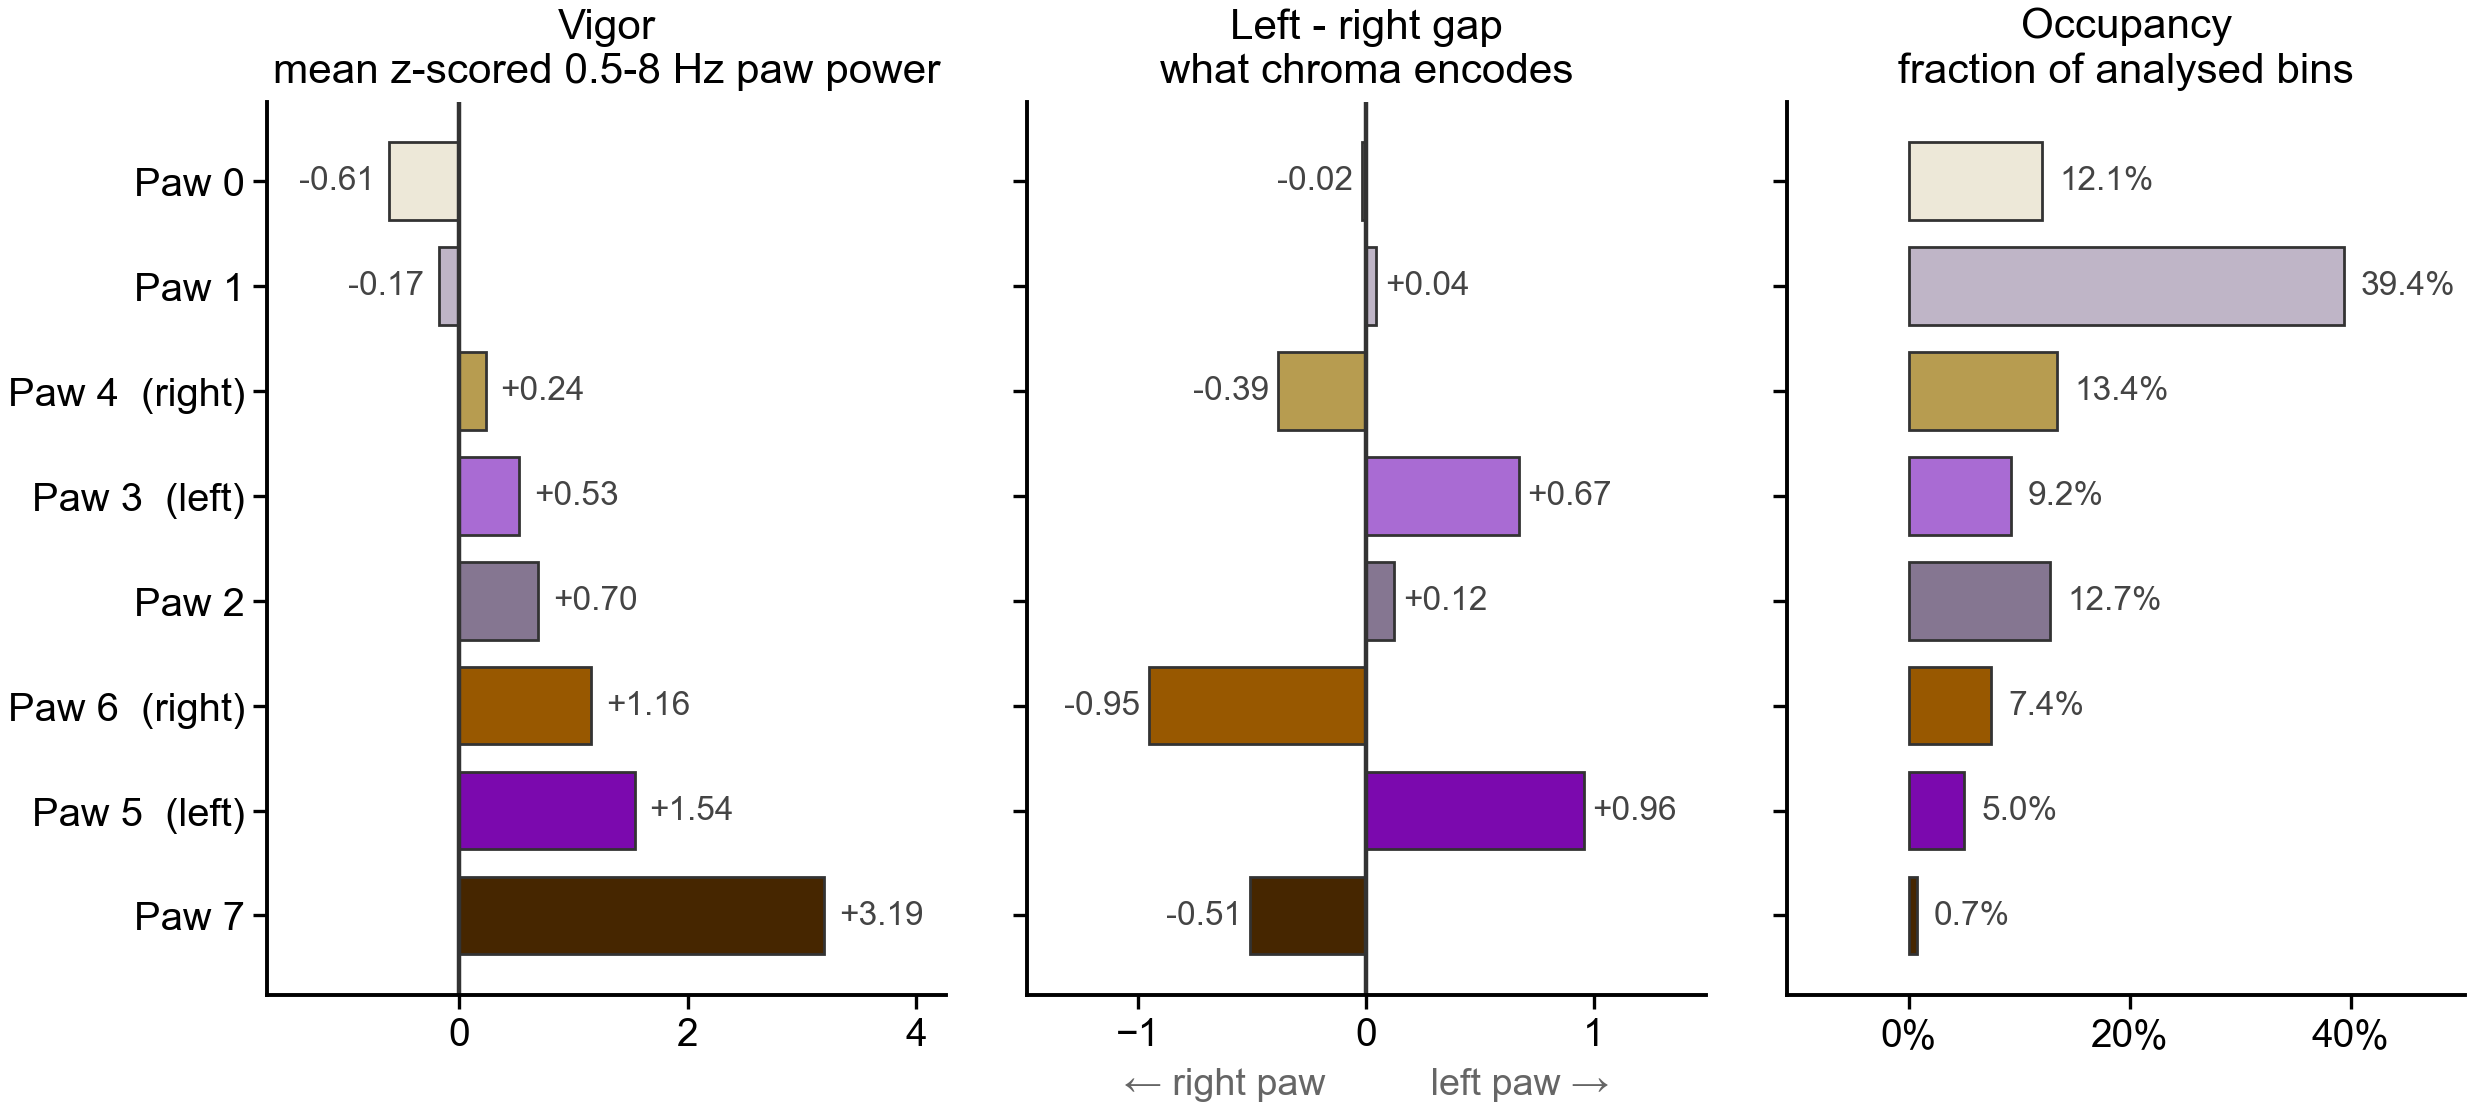

In [14]:
"""THE EIGHT STATES, CHARACTERISED -- vigor and left-right gap, in the palette itself."""
import sys
sys.path.insert(0, ROOT + '4_mice/laterality')      # laterality_features lives there
from laterality_features import state_laterality

# recomputed from the state wavelet profiles, never hardcoded, so a refit of the clustering
# changes this figure and the palette together
S = state_laterality()
S['gap'] = S['left'] - S['right']

# occupancy from THE FILE THIS NOTEBOOK USES, not the supersession the HMM was fit on --
# they differ (state 0 is 35.7% of all frames but 12.1% of the analysed trial bins), and the
# relevant one is what these panels actually draw
_all = np.concatenate(seq['binned_sequence'].to_numpy())
_paw = _all[~np.isnan(_all)].astype(int) % ps.N_PAW_STATES
S['occ'] = np.bincount(_paw, minlength=ps.N_PAW_STATES) / len(_paw)

order = list(ps.PAW_VIGOR_ORDER)
ypos = -np.arange(len(order))
bar_colors = [ps.PAW_STATE_COLORS[s] for s in order]

PANELS = [('overall', 'Vigor\nmean z-scored 0.5-8 Hz paw power', True),
          ('gap',     'Left - right gap\nwhat chroma encodes',   True),
          ('occ',     'Occupancy\nfraction of analysed bins',    False)]

fig, axes = plt.subplots(1, 3, figsize=(ps.FIG['double'][0], 2.9), sharey=True,
                         gridspec_kw=dict(wspace=0.12))
for ax, (col, title, diverging) in zip(axes, PANELS):
    vals = [S[col][s] for s in order]
    # a thin dark edge, because the pale states would otherwise have no visible bar
    ax.barh(ypos, vals, height=0.74, color=bar_colors, edgecolor='#333333', linewidth=0.5)
    if diverging:
        ax.axvline(0, color='#333333', lw=0.8)
    ax.set_title(title, fontsize=plt.rcParams['font.size'] * 0.95)
    ax.spines[['top', 'right']].set_visible(False)
    for y, v in zip(ypos, vals):
        ax.text(v + (0.04 if v >= 0 else -0.04) * max(abs(np.array(vals))), y,
                f'{v:+.2f}' if diverging else f'{v:.1%}',
                va='center', ha='left' if v >= 0 else 'right',
                fontsize=plt.rcParams['font.size'] * 0.75, color='#444')
    lo, hi = min(vals + [0]), max(vals + [0])
    ax.set_xlim(lo - 0.28 * (hi - lo), hi + 0.28 * (hi - lo))

axes[0].set_yticks(ypos)
axes[0].set_yticklabels([ps.paw_label(s) for s in order],
                        fontsize=plt.rcParams['font.size'] * 0.9)
axes[1].set_xlabel('\u2190 right paw          left paw \u2192',
                   fontsize=plt.rcParams['font.size'] * 0.85, color='#666')
axes[2].xaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
# fig.suptitle('The eight paw states, ordered by vigor', y=1.04)

ps.savefig(fig, 'paw_state_characterisation', svg=True)   # ps.saving(True) to write
plt.show()

### The two paws side by side, band by band

Each paw on its own, and now resolved into the five wavelet bands rather than averaged into
one number. Reading across the panels is how the palette was built: Paw 3 and 5 sit higher on
the left, Paw 4 and 6 higher on the right, and 0, 1, 2, 7 are near-symmetric — which is why
the first four carry hue and the rest are close to neutral.

**The spectrum shape is what the single vigor number throws away.** Two states can have the
same total power and be completely different movements:

- **2 and 7 fall with frequency** — large, slow movement. State 7 is the most powerful state
  in the set but almost all of it is at 0.5–1 Hz.
- **3, 5 and 6 rise with frequency** — small, fast movement. State 5 nearly doubles from
  0.5 to 8 Hz on the left paw, state 6 does the same on the right.

So lightness in the palette means *total* 0.5–8 Hz power, not speed. If a state's character
matters for how you describe it in text, read it off this figure rather than off vigor.

Both wavelet axes (x and y) are averaged, the same convention the vigor and gap panels use.

not saved (ps.SAVE_FIGURES is False): figures/paw_state_spectrum_27-09-2026.png, figures/paw_state_spectrum_27-09-2026.svg   -- ps.saving(True) to write, or pass save=True


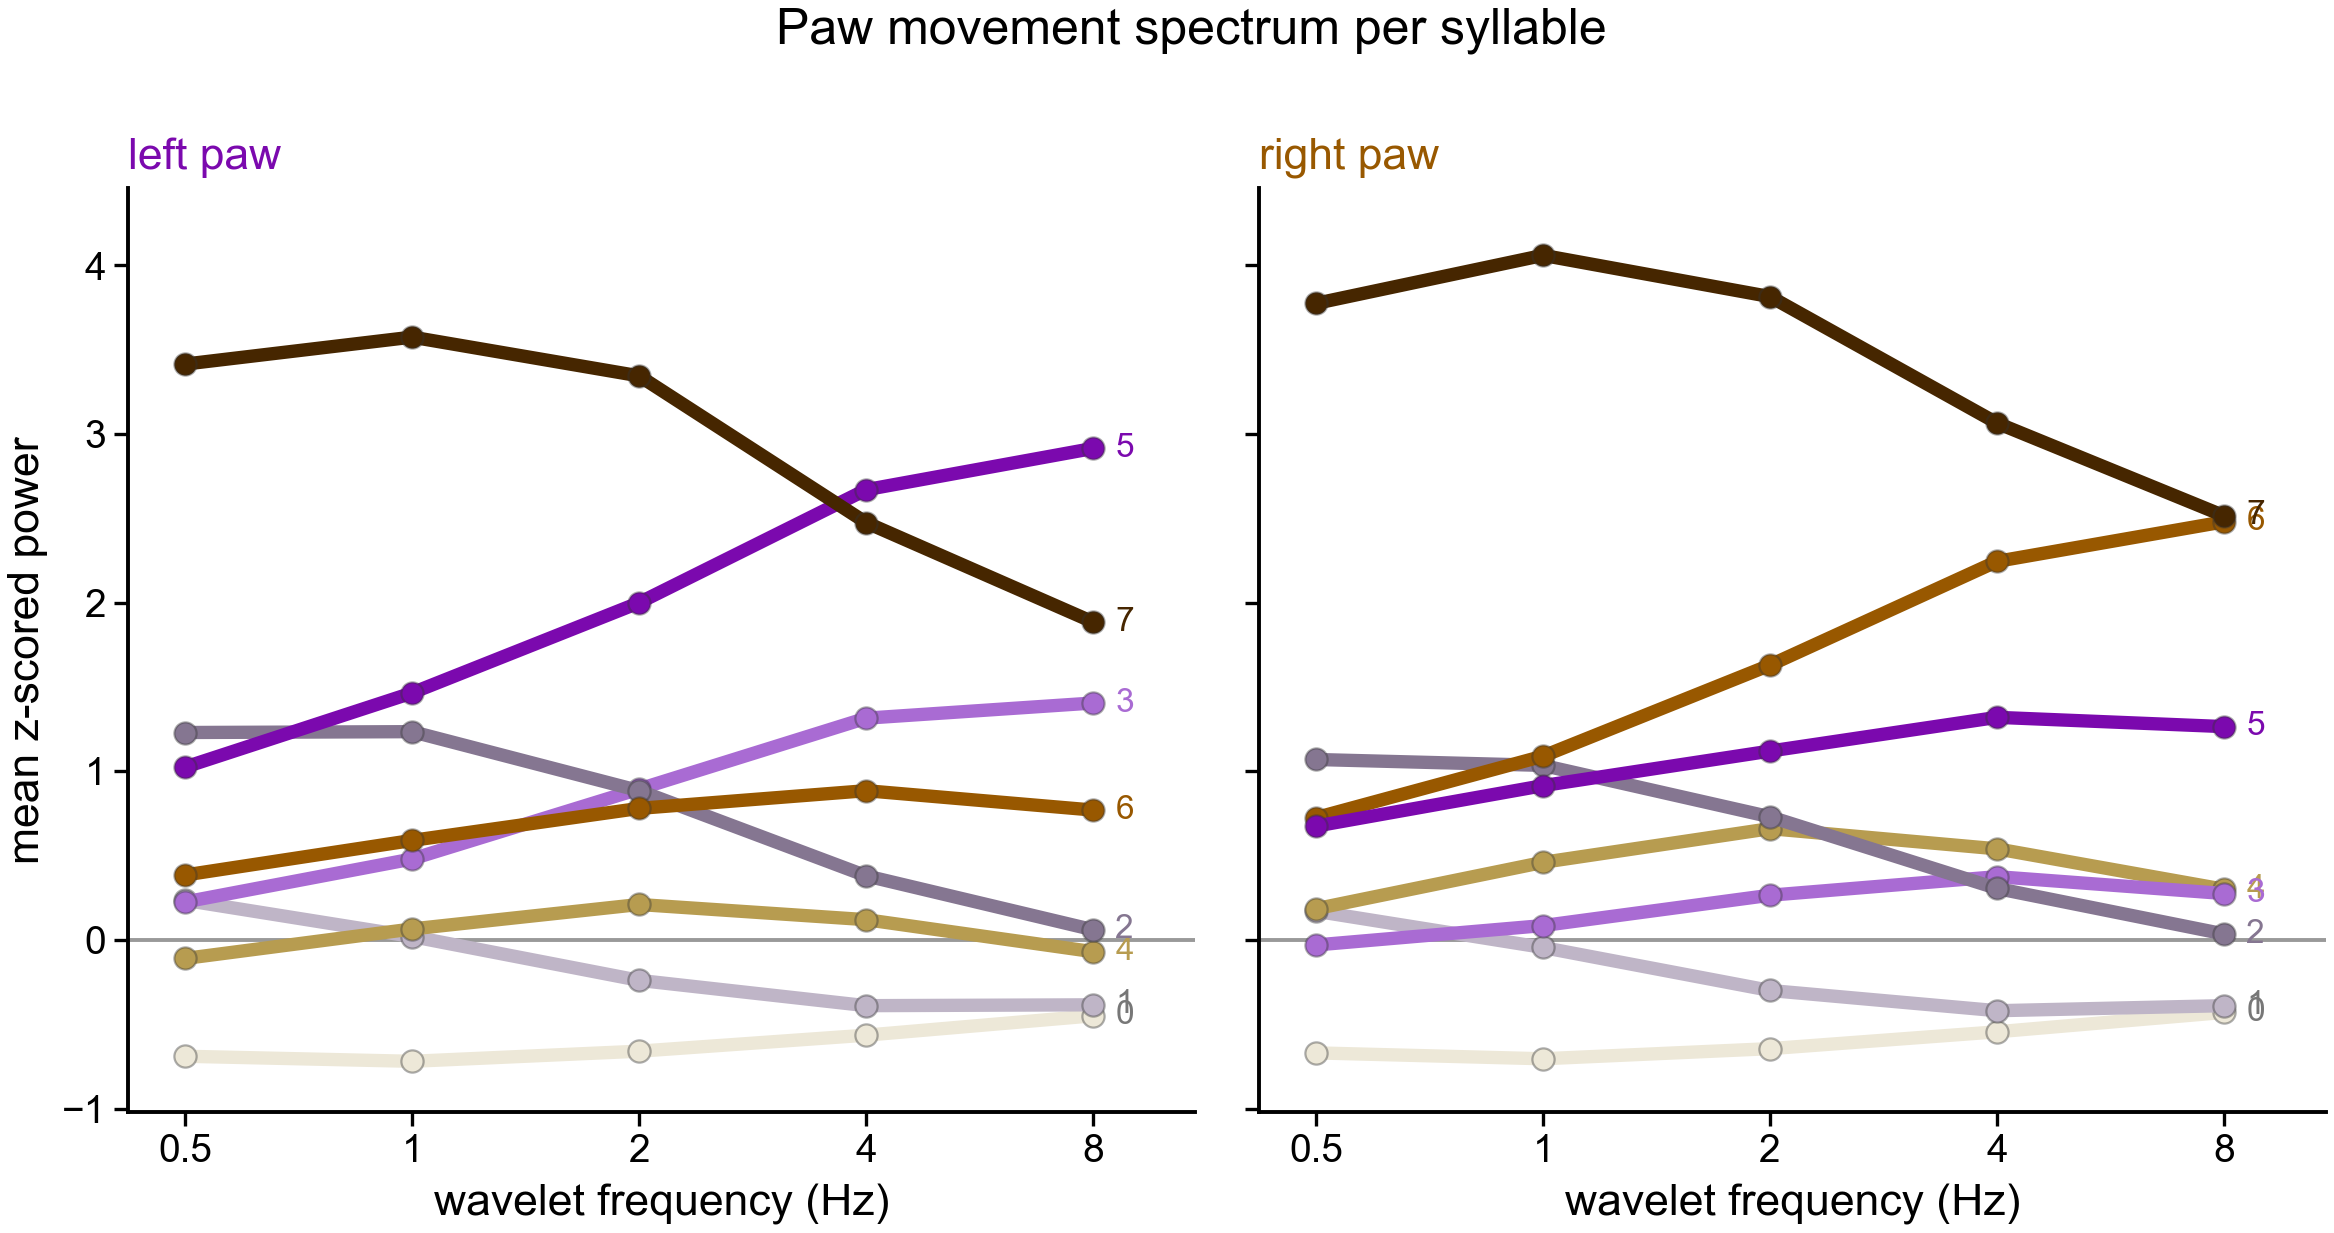

In [15]:
"""PAW MOVEMENT SPECTRUM PER SYLLABLE -- one panel per paw, one point per band."""
_prof = pd.read_csv(ROOT + 'segmentation/paw_bias/state_profiles_19Ago2026.csv').set_index('state')
FREQS = [0.5, 1.0, 2.0, 4.0, 8.0]          # the wavelet bands the profile table carries


def band_power(paw, f):
    """Mean z-scored power for one paw in one band, x and y averaged."""
    return _prof[[f'{paw}_paw_x{f}', f'{paw}_paw_y{f}']].mean(axis=1)


spectrum = {p: pd.DataFrame({f: band_power(p, f) for f in FREQS}) for p in ('l', 'r')}

_x = np.arange(len(FREQS))
_lo = min(spectrum['l'].values.min(), spectrum['r'].values.min())
_hi = max(spectrum['l'].values.max(), spectrum['r'].values.max())

# ONE y scale across both panels. Autoscaling each would make the two paws look equally
# active in every state, which is the thing this figure exists to disprove.
fig, axes = plt.subplots(1, 2, figsize=(ps.FIG['double'][0], 3.0), sharey=True,
                         gridspec_kw=dict(wspace=0.06))
for ax, (p, name, accent) in zip(axes, [('l', 'left paw', ps.PAW_LEFT),
                                        ('r', 'right paw', ps.PAW_RIGHT)]):
    ax.axhline(0, color='#999999', lw=0.7)
    for s in order:
        y = spectrum[p].loc[s].to_numpy()
        ax.plot(_x, y, color=ps.PAW_STATE_COLORS[s], lw=2.4, marker='o', ms=4,
                markeredgecolor='#33333366', markeredgewidth=0.4)
        # direct-labelled at the right edge; a legend for 8 near-neutral lines is unreadable
        ax.annotate(str(s), (_x[-1], y[-1]), xytext=(4, 0), textcoords='offset points',
                    va='center', fontsize=plt.rcParams['font.size'] * 0.75,
                    color=ps.PAW_STATE_COLORS[s] if s not in (0, 1) else '#777')
    ax.set_xticks(_x)
    ax.set_xticklabels([f'{f:g}' for f in FREQS])
    ax.set_xlim(-0.25, len(FREQS) - 0.55)
    ax.set_ylim(_lo - 0.3, _hi + 0.4)
    ax.set_xlabel('wavelet frequency (Hz)')
    ax.set_title(name, fontsize=plt.rcParams['font.size'], color=accent, loc='left')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('mean z-scored power')
fig.suptitle('Paw movement spectrum per syllable', y=1.03)

ps.savefig(fig, 'paw_state_spectrum', svg=True)   # ps.saving(True) to write
plt.show()

### Where the wavelets come from

The same snippet figure as the end of `1_segmentation/1_b.ipynb`, drawn in the paw palette so
the two notebooks agree about which paw is which: **violet = left, amber = right**, with the
frequency ladder as tints of each.

Top panel is raw horizontal paw position; bottom is its wavelet decomposition at 1, 2, 4 and
8 Hz — the quantity every other figure here is built on. It is worth seeing once, because the
state profiles, the vigor ordering and the left–right gap are all summaries of *this*.

Two departures from 1_b, both for legibility rather than content:

- **Stacked panels instead of twin y axes.** Ten traces on two scales in one frame is not
  readable; position and power get a panel each, sharing the x axis.
- **The window is chosen, not the first 500 samples** — the most active window in the
  session, so the snippet shows movement rather than whatever the recording opened with.

`l_paw_x` is halved throughout: the left camera is 1280×1024 against the right's 640×512, so
its pixels are twice the size. That is the same correction `get_speed` applies, and the
`paw_bias` README documents what happens when it is forgotten — it equates spatial scale but
also halves the left camera's tracking noise, which is the origin of the right-paw amplitude
artefact.

  CSH_ZAD_029 064a7252, window 1502-1511 s of 70 min
not saved (ps.SAVE_FIGURES is False): figures/paw_wavelet_snippet_27-09-2026.png, figures/paw_wavelet_snippet_27-09-2026.svg   -- ps.saving(True) to write, or pass save=True


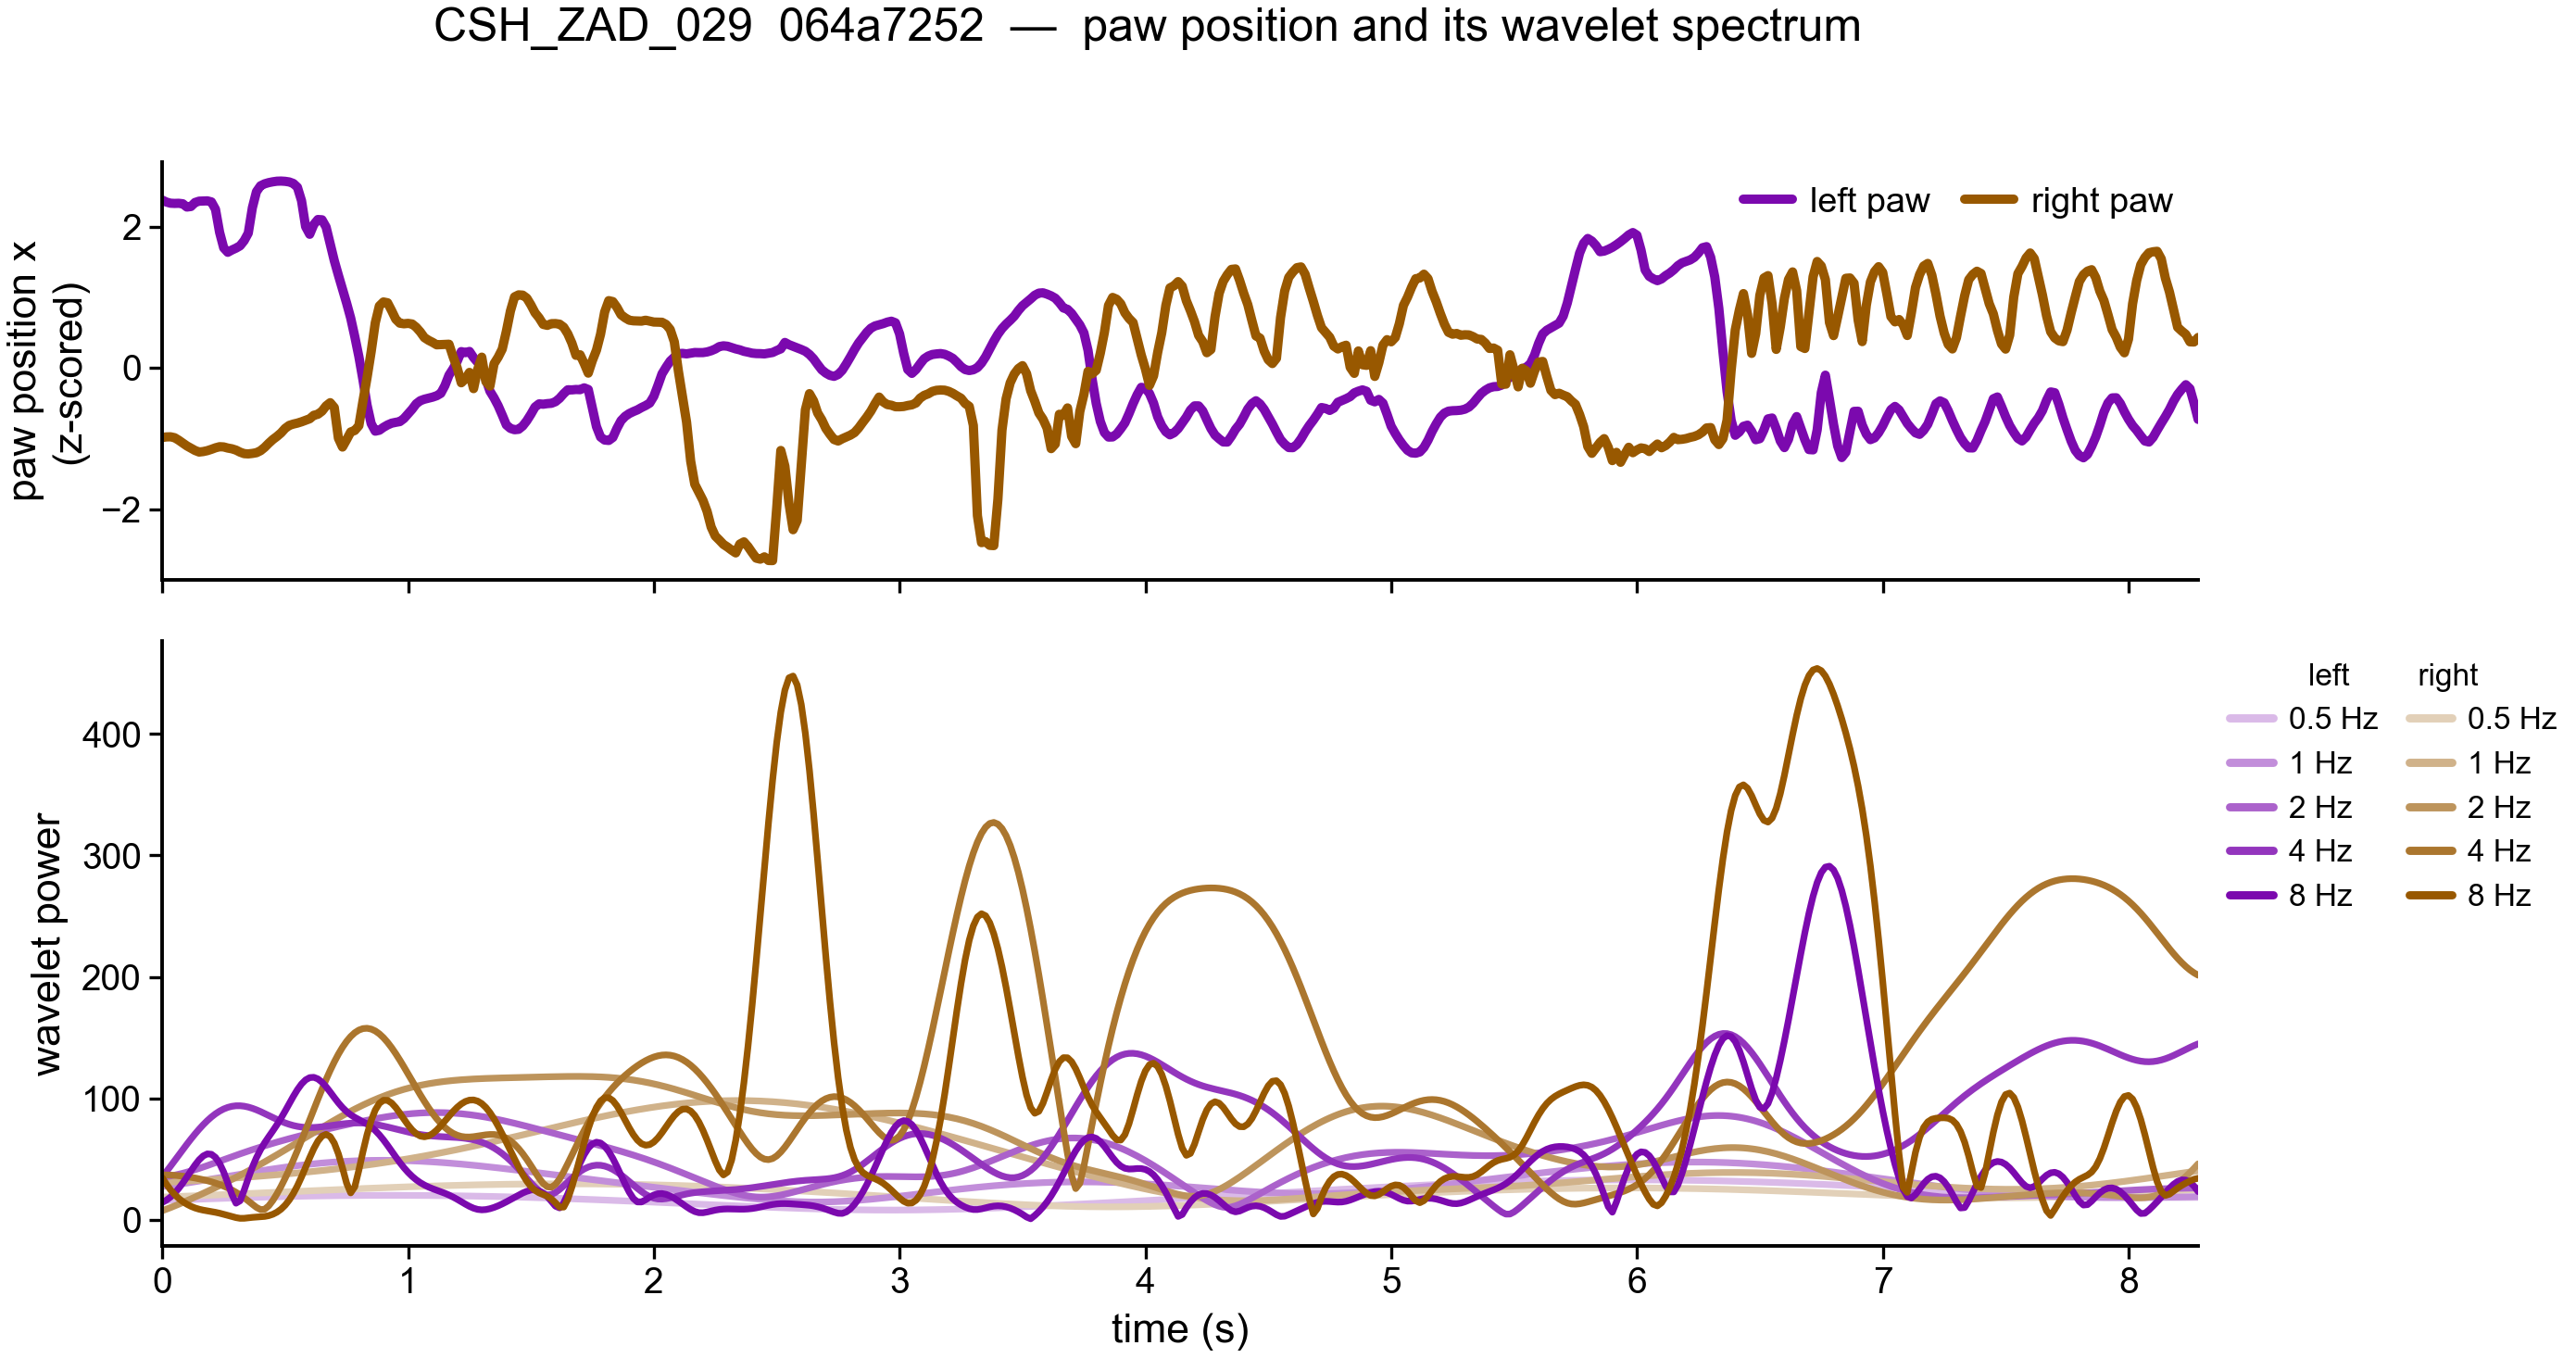

In [16]:
"""A SNIPPET OF PAW POSITION AND ITS WAVELET SPECTRUM."""
import glob, os
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D

SNIPPET_FREQS   = [0.5, 1.0, 2.0, 4.0, 8.0]   # 0.5, 16 and 32 Hz dropped, as in 1_b
SNIPPET_SECONDS = 8.3
SNIPPET_SESSION = None                   # None = the first session with wavelets AND an embedding
FS = 60.0                                # camera sampling rate

_wav = {os.path.basename(f).split('_')[3]: f
        for f in glob.glob(ROOT + 'data/paw_wavelets/*/paw_vel_wavelets_*')}
_shared = sorted(set(_wav) & set(emb['session']))
assert _shared, 'no session has both paw wavelets and an LDA embedding'
_sess = SNIPPET_SESSION or _shared[0]
_row = emb[emb['session'] == _sess].iloc[0]

_cols = (['l_paw_x', 'r_paw_x']
         + [f'{p}_paw_x{f}' for p in ('l', 'r') for f in SNIPPET_FREQS])
_D = pd.read_parquet(_wav[_sess])[_cols].dropna().to_numpy()

# THE MOST ACTIVE WINDOW, not the first. The recording opens with the mouse often still, and
# a snippet of a quiet stretch shows nothing about what the wavelets are decomposing.
_w = int(SNIPPET_SECONDS * FS)
_act = [np.nanstd(_D[i:i + _w, 0]) + np.nanstd(_D[i:i + _w, 1])
        for i in range(0, len(_D) - _w, _w)]
_s0 = int(np.argmax(_act)) * _w
d = _D[_s0:_s0 + _w]
t = np.arange(len(d)) / FS


def freq_ramp(hexcol, n, lightest=0.72):
    """n tints of ONE hue, light to full -- the frequency ladder within a paw."""
    base = np.array(to_rgb(hexcol))
    return [tuple(base * (1 - f) + f) for f in np.linspace(lightest, 0.0, n)]


Lr, Rr = freq_ramp(ps.PAW_LEFT, len(SNIPPET_FREQS)), freq_ramp(ps.PAW_RIGHT, len(SNIPPET_FREQS))

fig, (axp, axw) = plt.subplots(2, 1, sharex=True, figsize=(ps.FIG['double'][0], 3.8),
                               gridspec_kw=dict(height_ratios=[1, 1.45], hspace=0.12))
_z = lambda v: (v - v.mean()) / v.std()
# l_paw_x halved -- see the note above
axp.plot(t, _z(d[:, 0] / 2), color=ps.PAW_LEFT, lw=1.8, label='left paw')
axp.plot(t, _z(d[:, 1]), color=ps.PAW_RIGHT, lw=1.8, label='right paw')
axp.set_ylabel('paw position x\n(z-scored)')
axp.legend(fontsize=plt.rcParams['font.size'] * 0.85, frameon=False, ncol=2, loc='upper right')
axp.spines[['top', 'right']].set_visible(False)

for i in range(len(SNIPPET_FREQS)):
    axw.plot(t, d[:, 2 + i], color=Lr[i], lw=1.3)
    axw.plot(t, d[:, 2 + len(SNIPPET_FREQS) + i], color=Rr[i], lw=1.3)
axw.set_ylabel('wavelet power')
axw.set_xlabel('time (s)')
axw.set_xlim(t[0], t[-1])
axw.spines[['top', 'right']].set_visible(False)
axw.legend(handles=[Line2D([], [], color=Lr[i], lw=1.6, label=f'{f:g} Hz')
                    for i, f in enumerate(SNIPPET_FREQS)]
                 + [Line2D([], [], color=Rr[i], lw=1.6, label=f'{f:g} Hz')
                    for i, f in enumerate(SNIPPET_FREQS)],
           ncol=2, fontsize=plt.rcParams['font.size'] * 0.75, frameon=False,
           bbox_to_anchor=(1.005, 1), loc='upper left',
           title='left        right', title_fontsize=plt.rcParams['font.size'] * 0.75)

fig.suptitle(f'{_row["mouse_name"]}  {_sess[:8]}  \u2014  paw position and its wavelet spectrum',
             y=0.99)
print(f'  {_row["mouse_name"]} {_sess[:8]}, window {_s0 / FS:.0f}-{(_s0 + _w) / FS:.0f} s '
      f'of {len(_D) / FS / 60:.0f} min')

ps.savefig(fig, 'paw_wavelet_snippet', svg=True)   # ps.saving(True) to write
plt.show()

## Building the groups

`codes_for` returns raw `binned_sequence` codes — no renumbering. `ps.syllable_histogram`
unpacks them itself with `ps.decode_syllables`, which is what removed fig 2A's two
`identifiable_mapping` dictionaries.

In [17]:
def codes_for(rows):
    """(trials, bins) of RAW syllable codes for any subset of the sequence table."""
    piv = (rows.pivot(index=['sample'], columns=['broader_label'],
                      values='binned_sequence').dropna())
    if not len(piv):
        return np.empty((0, 10 * len(EPOCHS)))
    return np.vstack(piv[EPOCHS].apply(lambda r: np.hstack(r), axis=1)).astype(float)


def trial_field(frame, field):
    """One field out of the compound `trial_type` string, e.g. 'correct 0.25 0.8 right'."""
    return frame['trial_type'].str.split(' ').str[TRIAL_FIELDS.index(field)]


def make_groups():
    """-> [(panel title, codes), ...] for whatever GROUP_BY asks for."""
    if GROUP_BY == 'session':
        picks = seq['session'].value_counts().index[:N_GROUPS]
        return [(f"{seq.loc[seq['session'] == s, 'mouse_name'].iloc[0]}\n{s[:8]}",
                 codes_for(seq[seq['session'] == s])) for s in picks]

    if GROUP_BY == 'mouse':
        picks = seq['mouse_name'].value_counts().index[:N_GROUPS]
        return [(m, codes_for(seq[seq['mouse_name'] == m])) for m in picks]

    if GROUP_BY == 'trial_type':
        lvl = trial_field(seq, TRIAL_FIELD)
        keep = [l for l in sorted(lvl.dropna().unique())
                if (lvl == l).sum() >= MIN_TRIALS * len(EPOCHS)]
        dropped = sorted(set(lvl.dropna().unique()) - set(keep))
        if dropped:
            print(f'  below MIN_TRIALS and dropped: {dropped}')
        if TRIAL_FIELD == 'side':
            print("  NOTE 'side' comes from the choice strings, which are MIRRORED here -- "
                  "the panel labelled 'left' is the right side. Group on 'block' to orient.")
        return [(f'{TRIAL_FIELD} = {l}', codes_for(seq[lvl == l])) for l in keep]

    if GROUP_BY == 'ld_extremes':
        col = LD - 1
        have = emb[emb['session'].isin(seq['session'].unique())].sort_values(col)
        idx = np.linspace(0, len(have) - 1, N_GROUPS).round().astype(int)
        return [(f"LD{LD} = {have.iloc[i][col]:+.1f}\n{have.iloc[i]['mouse_name']}",
                 codes_for(seq[seq['session'] == have.iloc[i]['session']])) for i in idx]

    raise ValueError(f'GROUP_BY must be one of session|mouse|trial_type|ld_extremes, '
                     f'got {GROUP_BY!r}')

## Draw

One column per group. With `TEXTURE = True` (the default) that is a single panel carrying
all four channels — paw side and vigor in the colour, whisking and licking in the hatch —
and the panel is widened to whatever the hatch needs. With `TEXTURE = False` the whisk and
lick proportions go in a strip underneath instead.

Paw state 0 sits at the **top** of the stack, which is fig 2A's orientation (`imshow`'s
default `origin='upper'`) — `lowest_on_top=False` stacks upward instead.

  5 textured panels want a 23 in figure. A 40-bin panel needs ~4.6 in for the hatch to read, so texture suits 1-2 groups; lower N_GROUPS, or set TEXTURE = False for more.
  syllable_histogram: ~6 pt per bin, under the 12 a hatch needs -- widen the panel, show fewer bins, or use texture=False
  syllable_histogram: ~6 pt per bin, under the 12 a hatch needs -- widen the panel, show fewer bins, or use texture=False
  syllable_histogram: ~6 pt per bin, under the 12 a hatch needs -- widen the panel, show fewer bins, or use texture=False
  syllable_histogram: ~6 pt per bin, under the 12 a hatch needs -- widen the panel, show fewer bins, or use texture=False
  syllable_histogram: ~6 pt per bin, under the 12 a hatch needs -- widen the panel, show fewer bins, or use texture=False
not saved (ps.SAVE_FIGURES is False): figures/syllable_composition_session_27-09-2026.png, figures/syllable_composition_session_27-09-2026.svg   -- ps.saving(True) to write, or pass save=True


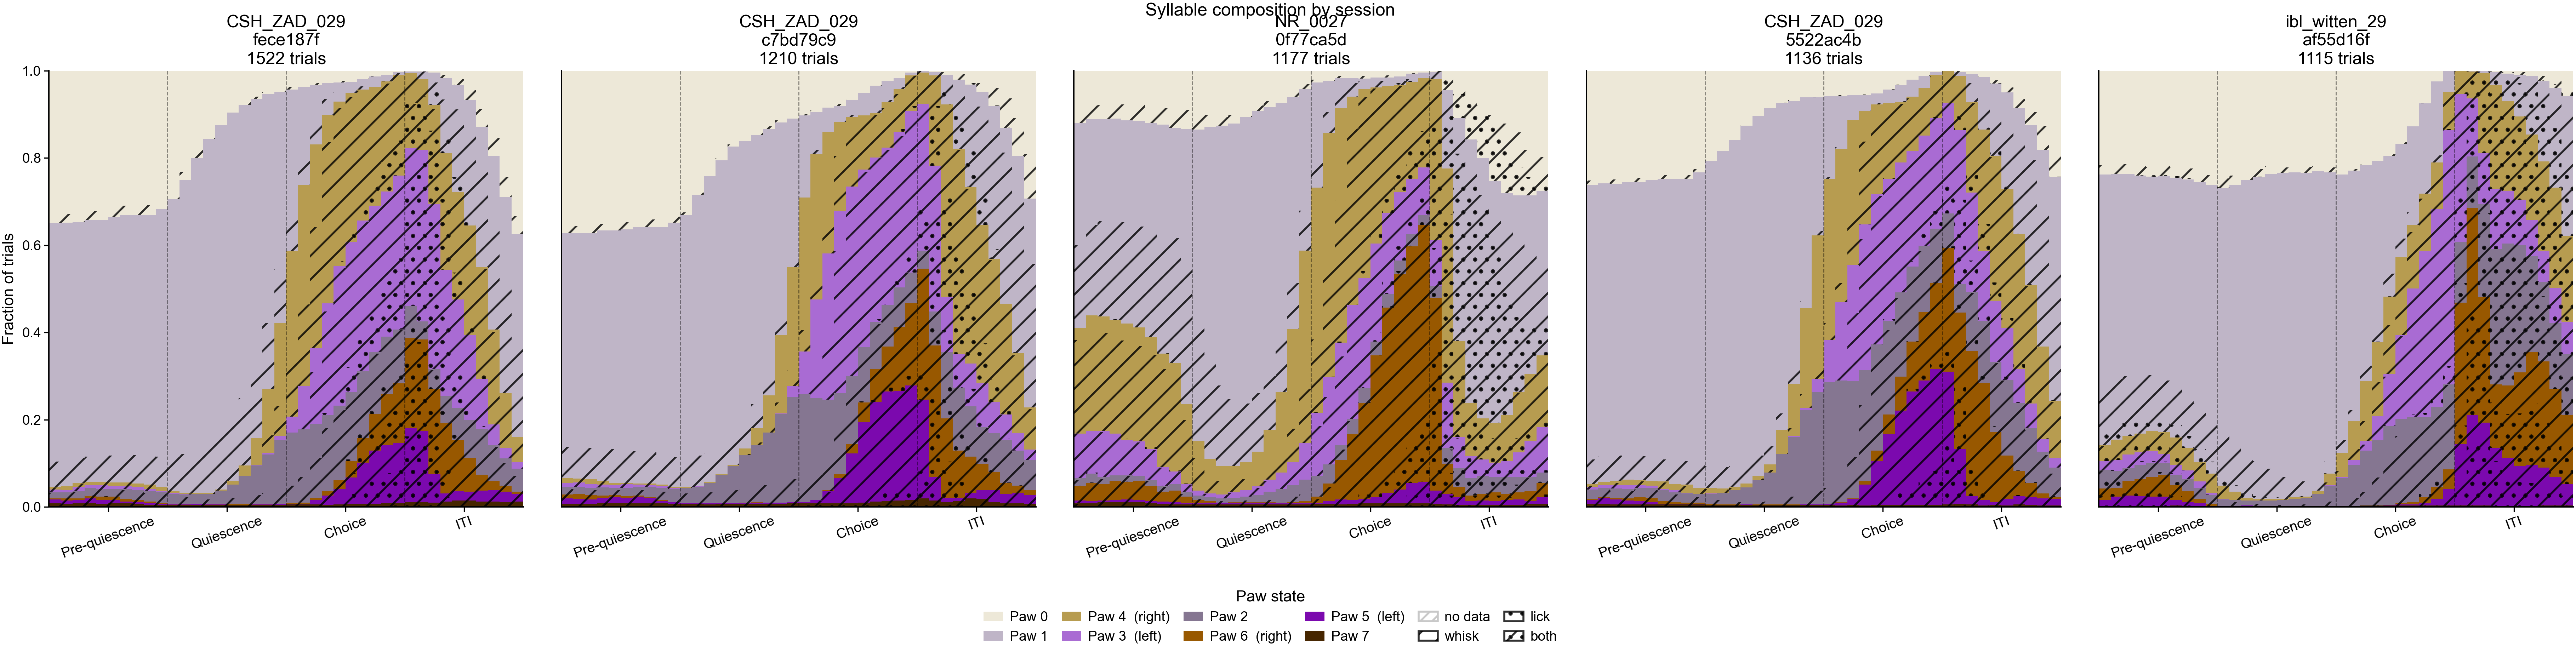

In [18]:
groups = make_groups()
n_bins = groups[0][1].shape[1]

# WIDTH IS SET BY THE TEXTURE, not by taste. A hatch needs ps.HATCH_MIN_PT per bin of
# DRAWN AXES, and the axes are only about 75% of their grid slot once labels, the y axis and
# wspace are taken out -- sizing the slot to 12 pt per bin gives 9 pt of actual axes, which
# is under the threshold. So divide by that fraction rather than discovering it from the
# warning syllable_histogram prints.
AXES_FRAC = 0.75
panel_w = n_bins * ps.HATCH_MIN_PT / 72 / AXES_FRAC if TEXTURE else 4.6
panel_w = 4.6

if TEXTURE and panel_w * len(groups) > 22:
    print(f'  {len(groups)} textured panels want a {panel_w * len(groups):.0f} in figure. '
          f'A 40-bin panel needs ~{panel_w:.1f} in for the hatch to read, so texture suits '
          f'1-2 groups; lower N_GROUPS, or set TEXTURE = False for more.')

fig = plt.figure(figsize=(panel_w * len(groups), 4.0 if TEXTURE else 4.4))
gs = (fig.add_gridspec(1, len(groups), wspace=0.08) if TEXTURE else
      fig.add_gridspec(2, len(groups), height_ratios=[3, 1], hspace=0.12, wspace=0.08))

for k, (name, codes) in enumerate(groups):
    ax = fig.add_subplot(gs[0, k] if not TEXTURE else gs[0, k])
    ps.syllable_histogram(codes, ax=ax, texture=TEXTURE)
    ps.epoch_lines(ax, codes.shape[1])
    ax.set_title(f'{name}\n{len(codes)} trials', fontsize=plt.rcParams['font.size'] * 1.1)

    if TEXTURE:
        # the texture already carries whisk and lick, so the strip would be redundant
        ax.set_xticks([5, 15, 25, 35])
        ax.set_xticklabels(EPOCHS, fontsize=plt.rcParams['font.size'] * 0.9, rotation=20)
        if k:
            ax.set_yticks([]); ax.set_ylabel('')
    else:
        ax.set_xticks([])
        axb = fig.add_subplot(gs[1, k])
        ps.whisk_lick_panel(codes, ax=axb)
        ps.epoch_lines(axb, codes.shape[1])
        axb.set_xticks([5, 15, 25, 35])
        axb.set_xticklabels(EPOCHS, fontsize=plt.rcParams['font.size'] * 0.9, rotation=20)
        if k:
            ax.set_yticks([]); ax.set_ylabel('')
            axb.set_yticks([]); axb.set_ylabel('')
        if k == len(groups) - 1:
            axb.legend(fontsize=plt.rcParams['font.size'] * 0.9, loc='upper left',
                       frameon=False)

ps.paw_legend(fig, ncol=6 if TEXTURE else 9, hatch=TEXTURE, bbox_to_anchor=(0.5, -0.02))
_sub = f' ({TRIAL_FIELD})' if GROUP_BY == 'trial_type' else ''
fig.suptitle(f'Syllable composition by {GROUP_BY}{_sub}', y=1.0)

ps.savefig(fig, f'syllable_composition_{GROUP_BY}', svg=True)   # ps.saving(True) to write
plt.show()